# Inequações Trigonométricas

**Módulo:** 05 – Trigonometria (8º notebook do módulo)

**Pré-requisitos:** [`0507a_equacoes.ipynb`](0507a_equacoes.ipynb) (resolver a equação correspondente é sempre o primeiro passo de uma inequação) e [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (gráficos e domínio das seis funções)

**Objetivos de aprendizagem:**
- Resolver as inequações fundamentais (sen x, cos x e tg x maior ou menor que um valor m), identificando o intervalo de soluções no ciclo trigonométrico.
- Resolver inequações envolvendo secante, cossecante e cotangente, reduzindo-as às inequações já conhecidas.
- Resolver sistemas de inequações trigonométricas, encontrando a interseção de duas ou mais condições.
- Construir uma ferramenta gráfica interativa que resolve e visualiza qualquer inequação trigonométrica simples.

**Tempo estimado:** 85 a 105 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/05_trigonometria/0508a_inequacoes_trigonometricas.ipynb)

No notebook anterior, descobrimos em que instantes a cadeira da roda-gigante está a exatamente 10 metros de altura. Mas, na prática, você provavelmente quer saber outra coisa: durante quanto tempo — e em quais intervalos — a cadeira fica **acima** de 10 metros? Essa pergunta não tem uma resposta pontual; tem uma resposta que é um intervalo de tempo. É exatamente isso que uma inequação trigonométrica responde.

In [1]:
import math
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)

## 1. Introdução e Inequações Fundamentais

Até agora, toda vez que escrevemos algo como sen x = 1/2, buscávamos pontos específicos — um conjunto discreto de soluções (mesmo que infinito, por causa da periodicidade). Uma **inequação trigonométrica** troca o sinal de igualdade por uma desigualdade (>, <, ≥ ou ≤), e a pergunta muda de natureza: em vez de "quais pontos satisfazem", perguntamos "em quais **intervalos**".

Como as funções circulares são periódicas, a resposta de uma inequação trigonométrica nunca é um intervalo isolado — é um intervalo que se repete indefinidamente, um por volta do ciclo. Por isso, assim como nas equações, é comum resolver primeiro dentro de uma única volta (um período) e depois generalizar somando múltiplos do período.

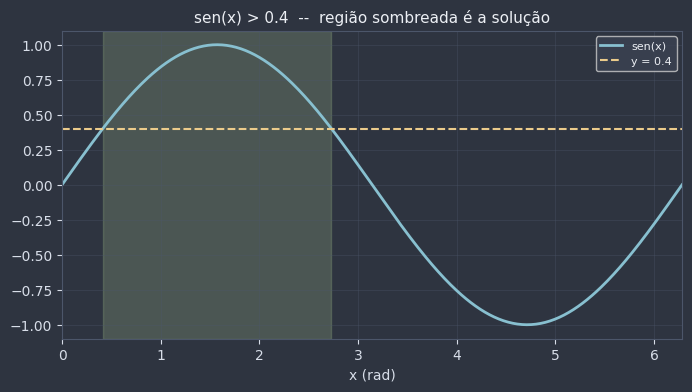

intervalos onde sen(x) > 0.4, em [0, 2π): [(np.float64(0.4117), np.float64(2.7292))]


In [2]:
def intervalos_da_mascara(xs: np.ndarray, mascara: np.ndarray) -> list[tuple[float, float]]:
    """Converte uma máscara booleana (mesmo tamanho de xs) nos subintervalos [início, fim] onde ela é True."""
    intervalos = []
    inicio = None
    for i, dentro in enumerate(mascara):
        if dentro and inicio is None:
            inicio = xs[i]
        elif not dentro and inicio is not None:
            intervalos.append((inicio, xs[i - 1]))
            inicio = None
    if inicio is not None:
        intervalos.append((inicio, xs[-1]))
    return intervalos


def encontrar_intervalos_solucao(
    funcao: Callable[[np.ndarray], np.ndarray],
    comparador: Callable[[np.ndarray, float], np.ndarray],
    valor_m: float,
    intervalo: tuple[float, float],
    n_pontos: int = 4000,
) -> list[tuple[float, float]]:
    """Varre o intervalo numa grade fina e devolve os subintervalos [início, fim]
    onde comparador(funcao(x), valor_m) é verdadeiro -- ex.: comparador=np.greater
    para f(x) > m. Pontos onde funcao(x) é NaN (assíntotas) nunca entram na solução."""
    xs = np.linspace(intervalo[0], intervalo[1], n_pontos)
    ys = funcao(xs)
    mascara = comparador(ys, valor_m) & ~np.isnan(ys)
    return intervalos_da_mascara(xs, mascara)


m_exemplo = 0.4
intervalos_exemplo = encontrar_intervalos_solucao(np.sin, np.greater, m_exemplo, (0, 2 * np.pi))

xs = np.linspace(0, 2 * np.pi, 400)
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, np.sin(xs), color=COR_PONTO, linewidth=2, label="sen(x)")
ax.axhline(m_exemplo, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {m_exemplo}")
for inicio, fim in intervalos_exemplo:
    ax.axvspan(inicio, fim, color=COR_DESTAQUE, alpha=0.25)

ax.set_xlim(0, 2 * np.pi)
ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
ax.set_title(f"sen(x) > {m_exemplo}  --  região sombreada é a solução", color=NORD_TEXTO, fontsize=11)
plt.show()

print(f"intervalos onde sen(x) > {m_exemplo}, em [0, 2π): {[(round(i, 4), round(f, 4)) for i, f in intervalos_exemplo]}")

📎 **Conexão:** a equação [`0507a_equacoes.ipynb`](0507a_equacoes.ipynb) sen x = m é justamente a "fronteira" da inequação sen x > m — resolver a equação é sempre o primeiro passo para entender onde a inequação muda de sinal.

**Pergunta de checagem:** se a solução de uma equação é um conjunto de pontos, o que muda na solução de uma inequação?

📖 **Leitura complementar:** [Inequação — Wikipédia](https://pt.wikipedia.org/wiki/Inequa%C3%A7%C3%A3o)

## 2. Resolução de sen x > m e sen x < m

No ciclo trigonométrico, o valor de sen x é a **ordenada** (altura) do ponto associado ao arco x. Para resolver sen x > m, trace a reta **horizontal** y = m; ela corta a circunferência em até dois pontos (se −1 ≤ m ≤ 1), dividindo-a em dois arcos: um onde a ordenada fica acima da reta (sen x > m) e outro onde fica abaixo (sen x < m).

🎯 **Aplicação prática — voltando à roda-gigante:** em [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) construímos altura_cadeira(t) = 15·sen((π/2)·t − π/2) + 15, com t em minutos e período de 4 minutos por volta. Em vez de perguntar "quando a cadeira está a exatamente 10 metros" (pergunta do notebook anterior), vamos resolver altura(t) > 10, encontrando os intervalos de tempo em que a cadeira fica acima dessa altura durante uma volta completa.

In [3]:
raio_roda = 15  # metros (mesmo valor de 0502a_funcoes_circulares)
periodo_roda = 4  # minutos
velocidade_angular = 2 * math.pi / periodo_roda  # rad/min


def altura_cadeira(t: np.ndarray) -> np.ndarray:
    """Altura da cadeira da roda-gigante (em metros) no instante t (em minutos) -- reaproveitada de 0502a_funcoes_circulares."""
    return raio_roda * np.sin(velocidade_angular * t - math.pi / 2) + raio_roda


alvo_altura = 10
intervalos_roda = encontrar_intervalos_solucao(altura_cadeira, np.greater, alvo_altura, (0, periodo_roda))

print(f"altura(t) > {alvo_altura} m dentro de uma volta: {[(round(i, 4), round(f, 4)) for i, f in intervalos_roda]}")

tempos_teste = [0, 0.5, 1, 2, 3, 3.5, 4]
tabela_teste = pd.DataFrame({
    "t (min)": tempos_teste,
    "altura(t) (m)": [round(float(altura_cadeira(np.array(t))), 2) for t in tempos_teste],
    "acima de 10 m?": [bool(altura_cadeira(np.array(t)) > alvo_altura) for t in tempos_teste],
})
tabela_teste

altura(t) > 10 m dentro de uma volta: [(np.float64(0.7842), np.float64(3.2158))]


,t (min),altura(t) (m),acima de 10 m?
0,0.0,0.00,False
1,0.5,4.39,False
2,1.0,15.00,True
3,2.0,30.00,True
4,3.0,15.00,True
5,3.5,4.39,False
6,4.0,0.00,False


🕹️ **Widget interativo:** mova o slider do valor de m e veja, lado a lado, o arco destacado no ciclo trigonométrico (esquerda) e a região sombreada no gráfico cartesiano de y = sen x (direita), para sen x > m.

In [ ]:
def resolver_e_plotar_sen(m: float) -> None:
    """Resolve sen(x) > m graficamente, mostrando o arco no ciclo trigonométrico e a região sombreada no gráfico cartesiano."""
    intervalos = encontrar_intervalos_solucao(np.sin, np.greater, m, (0, 2 * np.pi))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax1)
    estilizar_eixo(ax2)

    angulos = np.linspace(0, 2 * math.pi, 300)
    ax1.plot(np.cos(angulos), np.sin(angulos), color=NORD_LINHA, linewidth=1.5)
    ax1.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax1.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax1.axhline(m, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {m}")
    for inicio, fim in intervalos:
        arco = np.linspace(inicio, fim, 100)
        ax1.plot(np.cos(arco), np.sin(arco), color=COR_DESTAQUE, linewidth=4)
    ax1.set_xlim(-1.3, 1.3)
    ax1.set_ylim(-1.3, 1.3)
    ax1.set_aspect("equal")
    ax1.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="lower right")
    ax1.set_title("ciclo trigonométrico", color=NORD_TEXTO, fontsize=11)

    xs = np.linspace(0, 2 * math.pi, 400)
    ax2.plot(xs, np.sin(xs), color=COR_PONTO, linewidth=2, label="sen(x)")
    ax2.axhline(m, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {m}")
    for inicio, fim in intervalos:
        ax2.axvspan(inicio, fim, color=COR_DESTAQUE, alpha=0.25)
    ax2.set_xlim(0, 2 * math.pi)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
    ax2.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
    ax2.set_title("gráfico cartesiano", color=NORD_TEXTO, fontsize=11)

    plt.show()
    print(f"sen(x) > {m}, em [0, 2π): {[(round(i, 4), round(f, 4)) for i, f in intervalos]}")


widgets.interact(
    resolver_e_plotar_sen,
    m=widgets.FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.4, description="m"),
)

interactive(children=(FloatSlider(value=0.4, description='m', max=1.0, min=-1.0, step=0.05), Output()), _dom_c…

<function __main__.resolver_e_plotar_sen(m: float) -> None>

📌 **Técnica geral — sen x > m e sen x < m:** trace a reta horizontal y = m no ciclo trigonométrico. Os pontos onde ela corta a circunferência dividem o ciclo em dois arcos: o arco "de cima" é a solução de sen x > m; o arco "de baixo" (complementar) é a solução de sen x < m. Repita a cada volta somando 2kπ (k inteiro) para obter a solução geral.

**Pergunta de checagem:** se m estiver fora do intervalo [−1, 1], o que acontece com a inequação sen x > m (ou sen x < m)?

## 3. Resolução de cos x > m e cos x < m

A mesma ideia do bloco anterior se aplica ao cosseno, mas com um corte diferente: como cos x é a **abscissa** do ponto no ciclo trigonométrico, a reta de referência agora é a **vertical** x = m. A região à direita dessa reta (mais próxima da origem dos arcos) é onde cos x > m; a região à esquerda é onde cos x < m.

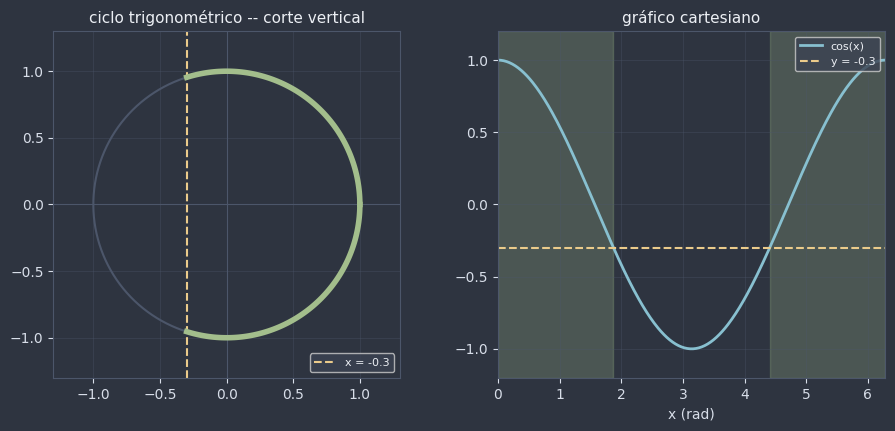

cos(x) > -0.3, em [0, 2π): [(np.float64(0.0), np.float64(1.8744)), (np.float64(4.4088), np.float64(6.2832))]


In [5]:
m_cos = -0.3
intervalos_cos = encontrar_intervalos_solucao(np.cos, np.greater, m_cos, (0, 2 * np.pi))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax1)
estilizar_eixo(ax2)

angulos = np.linspace(0, 2 * math.pi, 300)
ax1.plot(np.cos(angulos), np.sin(angulos), color=NORD_LINHA, linewidth=1.5)
ax1.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax1.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax1.axvline(m_cos, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"x = {m_cos}")
for inicio, fim in intervalos_cos:
    arco = np.linspace(inicio, fim, 100)
    ax1.plot(np.cos(arco), np.sin(arco), color=COR_DESTAQUE, linewidth=4)
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-1.3, 1.3)
ax1.set_aspect("equal")
ax1.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="lower right")
ax1.set_title("ciclo trigonométrico -- corte vertical", color=NORD_TEXTO, fontsize=11)

xs = np.linspace(0, 2 * math.pi, 400)
ax2.plot(xs, np.cos(xs), color=COR_PONTO, linewidth=2, label="cos(x)")
ax2.axhline(m_cos, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {m_cos}")
for inicio, fim in intervalos_cos:
    ax2.axvspan(inicio, fim, color=COR_DESTAQUE, alpha=0.25)
ax2.set_xlim(0, 2 * math.pi)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
ax2.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
ax2.set_title("gráfico cartesiano", color=NORD_TEXTO, fontsize=11)

plt.show()
print(f"cos(x) > {m_cos}, em [0, 2π): {[(round(i, 4), round(f, 4)) for i, f in intervalos_cos]}")

💡 **Dica:** pense sempre "seno = corte horizontal, cosseno = corte vertical" — essa associação evita confundir qual reta desenhar em cada caso.

**Pergunta de checagem:** por que a inequação cos x > 0 tem como solução justamente o 1º e o 4º quadrantes?

## 4. Resolução de tg x > m e tg x < m

A tangente é mais fácil de visualizar diretamente no gráfico cartesiano: ela é crescente em cada "ramo" entre duas assíntotas consecutivas, com período π. Para resolver, trace a reta horizontal y = m sobre o próprio gráfico de y = tg x e identifique em que trecho de cada ramo a tangente fica acima ou abaixo dessa reta.

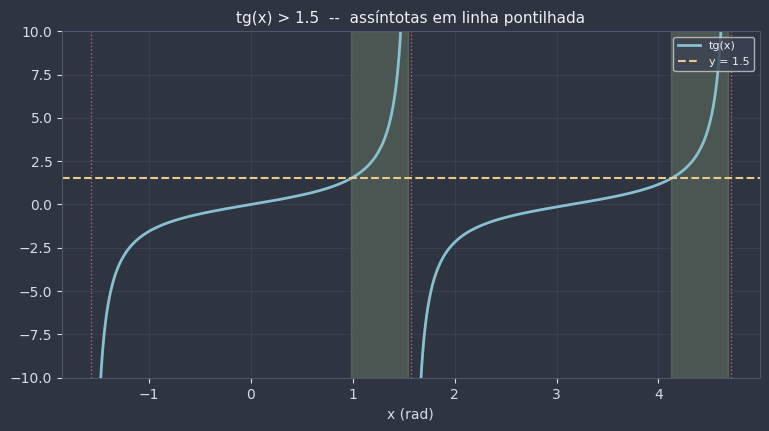

tg(x) > 1.5, em [-1.5708, 4.7124]: [(np.float64(0.984), np.float64(1.5402)), (np.float64(4.1248), np.float64(4.681))]


In [6]:
def tangente_com_assintotas(x: np.ndarray) -> np.ndarray:
    """Calcula tg(x), com NaN perto das assíntotas para não conectar os ramos (reaproveitada de 0502a_funcoes_circulares)."""
    cos_x = np.cos(x)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(cos_x) < 0.03, np.nan, np.sin(x) / cos_x)


m_tg = 1.5
intervalo_tg = (-math.pi / 2, 3 * math.pi / 2)  # dois ramos completos
intervalos_solucao_tg = encontrar_intervalos_solucao(tangente_com_assintotas, np.greater, m_tg, intervalo_tg)

xs = np.linspace(intervalo_tg[0], intervalo_tg[1], 3000)
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(xs, tangente_com_assintotas(xs), color=COR_PONTO, linewidth=2, label="tg(x)")
ax.axhline(m_tg, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {m_tg}")
for inicio, fim in intervalos_solucao_tg:
    ax.axvspan(inicio, fim, color=COR_DESTAQUE, alpha=0.25)
for k in (-1, 0, 1):
    ax.axvline(math.pi / 2 + k * math.pi, color=COR_ALERTA, linewidth=1, linestyle=":")

ax.set_ylim(-10, 10)
ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
ax.set_title(f"tg(x) > {m_tg}  --  assíntotas em linha pontilhada", color=NORD_TEXTO, fontsize=11)
plt.show()
print(f"tg(x) > {m_tg}, em [{intervalo_tg[0]:.4f}, {intervalo_tg[1]:.4f}]: {[(round(i, 4), round(f, 4)) for i, f in intervalos_solucao_tg]}")

⚠️ **Erro comum:** esquecer que a tangente não está definida nas assíntotas (x = π/2 + kπ); por isso, o intervalo de solução nunca pode incluir esses pontos — use sempre intervalo aberto ali, mesmo quando a desigualdade original não é estrita (≥ ou ≤).

**Pergunta de checagem:** por que a solução de tg x > m é sempre um intervalo aberto nas assíntotas, mesmo quando a desigualdade em relação a m não é estrita?

## 5. Inequações envolvendo Secante, Cossecante e Cotangente

Essas três inequações se reduzem às já conhecidas usando as relações recíprocas: sec x = 1/cos x, cossec x = 1/sen x e cotg x = 1/tg x. O cuidado extra é com o **sinal**: ao "inverter" uma desigualdade (por exemplo, passar de sec x > m para uma condição sobre cos x), o sinal da expressão original importa — inverter uma fração cujo sinal pode mudar também pode trocar o sentido da desigualdade.

In [7]:
def secante(x: np.ndarray) -> np.ndarray:
    """Calcula sec(x) = 1/cos(x), com NaN perto das assíntotas."""
    cos_x = np.cos(x)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(cos_x) < 0.03, np.nan, 1 / cos_x)


def cossecante(x: np.ndarray) -> np.ndarray:
    """Calcula cossec(x) = 1/sen(x), com NaN perto das assíntotas."""
    sen_x = np.sin(x)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(sen_x) < 0.03, np.nan, 1 / sen_x)


def cotangente(x: np.ndarray) -> np.ndarray:
    """Calcula cotg(x) = cos(x)/sen(x), com NaN perto das assíntotas."""
    sen_x = np.sin(x)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(sen_x) < 0.03, np.nan, np.cos(x) / sen_x)


m_sec = 2
intervalos_sec = encontrar_intervalos_solucao(secante, np.greater, m_sec, (0, 2 * math.pi))
print(f"sec(x) > {m_sec}, direto: {[(round(i, 4), round(f, 4)) for i, f in intervalos_sec]}")

# sec x > 2 (positiva) só é possível com cos x > 0, e nesse caso
# sec x > 2 <=> cos x < 1/2 -- ou seja, a interseção das duas condições
# 0 < cos x < 1/2
xs_sec = np.linspace(0, 2 * math.pi, 4000)
cos_xs = np.cos(xs_sec)
mascara_reduzida = (cos_xs < 1 / m_sec) & (cos_xs > 0)
intervalos_reduzidos = intervalos_da_mascara(xs_sec, mascara_reduzida)
print(f"reduzindo a 0 < cos x < 1/{m_sec}: {[(round(i, 4), round(f, 4)) for i, f in intervalos_reduzidos]}")

# a margem de ~0.03 rad entre os dois métodos vem do buffer de NaN perto da
# assíntota (onde sec(x) diverge); ela some se refinarmos o buffer
concordam = len(intervalos_sec) == len(intervalos_reduzidos) and all(
    abs(a - b) < 0.05 and abs(c - d) < 0.05
    for (a, c), (b, d) in zip(intervalos_sec, intervalos_reduzidos)
)
assert concordam, "os dois métodos deveriam concordar (a menos da margem perto da assíntota)"
print("\nOs dois métodos concordam (a menos da pequena margem perto da assíntota, onde sec(x) diverge).")

sec(x) > 2, direto: [(np.float64(1.048), np.float64(1.5398)), (np.float64(4.7434), np.float64(5.2352))]
reduzindo a 0 < cos x < 1/2: [(np.float64(1.048), np.float64(1.5696)), (np.float64(4.7136), np.float64(5.2352))]

Os dois métodos concordam (a menos da pequena margem perto da assíntota, onde sec(x) diverge).


⚠️ **Erro comum:** esquecer de trocar o sentido da desigualdade ao inverter uma fração cujo sinal pode mudar — por exemplo, sec x > 2 não vira diretamente cos x < 1/2 para todo x; a equivalência só vale onde cos x > 0 (fora daí, sec x é negativa e a inequação sec x > 2 nunca é satisfeita).

**Pergunta de checagem:** ao transformar cossec x < m em sen x > 1/m (ou o contrário), em que casos o sentido da desigualdade muda?

## 6. Sistemas de Inequações Trigonométricas

Um sistema de inequações trigonométricas se resolve com a mesma técnica de qualquer sistema de inequações: resolva cada uma separadamente e depois encontre a **interseção** dos conjuntos solução.

🎯 **Aplicação prática — personagem de jogo:** um personagem de um jogo 2D pula seguindo uma trajetória senoidal, altura(t) = A·sen(ωt) + B. Vamos encontrar os intervalos de tempo em que o personagem está **simultaneamente** acima do chão (altura(t) > 0) e abaixo do teto (altura(t) < altura máxima permitida) — um sistema de duas inequações sobre a mesma função.

In [8]:
amplitude_personagem = 3  # metros
frequencia_angular_personagem = 1.5  # rad/s
deslocamento_personagem = 2  # metros


def altura_personagem(t: np.ndarray) -> np.ndarray:
    """Altura do personagem (em metros) no instante t (em segundos)."""
    return amplitude_personagem * np.sin(frequencia_angular_personagem * t) + deslocamento_personagem


teto_personagem = 4  # metros
periodo_personagem = 2 * math.pi / frequencia_angular_personagem

tempos = np.linspace(0, periodo_personagem, 4000)
alturas = altura_personagem(tempos)
mascara_sistema = (alturas > 0) & (alturas < teto_personagem)
intervalos_sistema = intervalos_da_mascara(tempos, mascara_sistema)

print(f"intervalos com 0 < altura(t) < {teto_personagem} m, em um período: "
      f"{[(round(i, 4), round(f, 4)) for i, f in intervalos_sistema]}")

intervalos com 0 < altura(t) < 4 m, em um período: [(np.float64(0.0), np.float64(0.486)), (np.float64(1.6089), np.float64(2.5799)), (np.float64(3.7028), np.float64(4.1888))]


🕹️ **Widget interativo:** mova os sliders do "chão" e do "teto" e veja ao vivo a trajetória do personagem, com os intervalos de tempo dentro da faixa permitida destacados em uma cor diferente.

In [ ]:
def plotar_sistema_personagem(chao: float, teto: float) -> None:
    """Plota a trajetória do personagem e destaca os intervalos em que chao < altura(t) < teto."""
    tempos = np.linspace(0, periodo_personagem, 4000)
    alturas = altura_personagem(tempos)
    mascara = (alturas > chao) & (alturas < teto)
    intervalos = intervalos_da_mascara(tempos, mascara)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(tempos, alturas, color=COR_PONTO, linewidth=2, label="altura(t)")
    ax.axhline(chao, color=COR_ALERTA, linewidth=1.5, linestyle="--", label=f"chão = {chao} m")
    ax.axhline(teto, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"teto = {teto} m")
    for inicio, fim in intervalos:
        ax.axvspan(inicio, fim, color=COR_DESTAQUE, alpha=0.25)

    ax.set_xlim(0, periodo_personagem)
    ax.set_xlabel("tempo (s)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("altura (m)", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
    ax.set_title("intervalos em que o personagem está dentro da faixa permitida", color=NORD_TEXTO, fontsize=11)
    plt.show()
    print(f"intervalos: {[(round(i, 4), round(f, 4)) for i, f in intervalos]}")


widgets.interact(
    plotar_sistema_personagem,
    chao=widgets.FloatSlider(min=-1.0, max=3.0, step=0.1, value=0.0, description="chão"),
    teto=widgets.FloatSlider(min=1.0, max=5.0, step=0.1, value=4.0, description="teto"),
)

interactive(children=(FloatSlider(value=0.0, description='chão', max=3.0, min=-1.0), FloatSlider(value=4.0, de…

<function __main__.plotar_sistema_personagem(chao: float, teto: float) -> None>

📎 **Conexão:** os parâmetros amplitude, período/frequência angular e deslocamento vertical de altura(t) seguem a forma geral y = a·sen(bx+c)+d, apresentada em [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb), Bloco 5.

**Pergunta de checagem:** se duas inequações de um sistema não tiverem nenhum intervalo em comum, o que isso significa sobre a solução do sistema?

## 7. Aplicação Final: Resolução Gráfica Interativa

Vamos consolidar tudo construindo uma ferramenta genérica: dado o tipo de função (sen, cos ou tg), o valor de m e o tipo de desigualdade (>, <, ≥, ≤), a ferramenta calcula e desenha automaticamente a região solução.

🎯 **Aplicação prática (síntese):** use a ferramenta abaixo para resolver de novo, em segundos, os problemas da roda-gigante (Bloco 2) e do personagem de jogo (Bloco 6), conferindo os resultados já encontrados manualmente.

🕹️ **Widget interativo:** escolha a função, o valor de m e o tipo de desigualdade, e veja o gráfico com a região sombreada e o conjunto solução escrito por extenso.

In [ ]:
FUNCOES_DISPONIVEIS: dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "sen": np.sin,
    "cos": np.cos,
    "tg": tangente_com_assintotas,
}

COMPARADORES: dict[str, Callable[[np.ndarray, float], np.ndarray]] = {
    ">": np.greater,
    "<": np.less,
    "≥": np.greater_equal,
    "≤": np.less_equal,
}


def ferramenta_inequacao(funcao_nome: str, m: float, desigualdade: str) -> None:
    """Resolve e plota funcao_nome(x) <desigualdade> m no intervalo de referência."""
    funcao = FUNCOES_DISPONIVEIS[funcao_nome]
    comparador = COMPARADORES[desigualdade]
    intervalo_base = (0, 2 * math.pi) if funcao_nome != "tg" else (-math.pi / 2, 3 * math.pi / 2)
    intervalos = encontrar_intervalos_solucao(funcao, comparador, m, intervalo_base)

    xs = np.linspace(intervalo_base[0], intervalo_base[1], 3000)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(xs, funcao(xs), color=COR_PONTO, linewidth=2, label=f"{funcao_nome}(x)")
    ax.axhline(m, color=COR_AVISO, linewidth=1.5, linestyle="--", label=f"y = {m}")
    for inicio, fim in intervalos:
        ax.axvspan(inicio, fim, color=COR_DESTAQUE, alpha=0.25)
    if funcao_nome == "tg":
        ax.set_ylim(-10, 10)
        for k in (-1, 0, 1):
            ax.axvline(math.pi / 2 + k * math.pi, color=COR_ALERTA, linewidth=1, linestyle=":")
    else:
        ax.set_ylim(-1.2, 1.2)

    ax.set_xlim(intervalo_base[0], intervalo_base[1])
    ax.set_xlabel("x (rad)", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8, loc="upper right")
    ax.set_title(f"{funcao_nome}(x) {desigualdade} {m}", color=NORD_TEXTO, fontsize=11)
    plt.show()

    solucao_texto = " ou ".join(f"({round(i, 3)}, {round(f, 3)})" for i, f in intervalos) or "conjunto vazio"
    print(f"conjunto solução em [{intervalo_base[0]:.4f}, {intervalo_base[1]:.4f}]: {solucao_texto}")


widgets.interact(
    ferramenta_inequacao,
    funcao_nome=widgets.Dropdown(options=["sen", "cos", "tg"], value="sen", description="função"),
    m=widgets.FloatSlider(min=-2.0, max=2.0, step=0.05, value=0.5, description="m"),
    desigualdade=widgets.Dropdown(options=[">", "<", "≥", "≤"], value=">", description="desigualdade"),
)

interactive(children=(Dropdown(description='função', options=('sen', 'cos', 'tg'), value='sen'), FloatSlider(v…

<function __main__.ferramenta_inequacao(funcao_nome: str, m: float, desigualdade: str) -> None>

📌 **Síntese do processo geral** para resolver f(x) {>, <, ≥, ≤} m, com f sendo sen, cos ou tg:
1. Identifique a função e "corte" com a reta de referência certa (horizontal para seno, vertical para cosseno, horizontal sobre o próprio gráfico para tangente).
2. Encontre os pontos de interseção (resolvendo a equação f(x) = m) e determine qual lado do corte satisfaz a desigualdade.
3. Escreva o intervalo de solução dentro de uma volta e generalize somando o período (2kπ para seno/cosseno, kπ para tangente).

**Pergunta de checagem:** dos três passos do processo geral, qual costuma exigir mais atenção para não errar o sinal ou esquecer uma família de soluções?

📖 **Leitura complementar:** [Intervalo (matemática) — Wikipédia](https://pt.wikipedia.org/wiki/Intervalo_(matem%C3%A1tica))

## Resumo — cheat sheet

**Inequações fundamentais e a técnica geométrica de cada uma:**

| Inequação | Técnica |
|---|---|
| sen x > m (ou <) | corte **horizontal** y = m no ciclo trigonométrico; o arco "de cima" é sen x > m |
| cos x > m (ou <) | corte **vertical** x = m no ciclo trigonométrico; a região à direita é cos x > m |
| tg x > m (ou <) | reta horizontal y = m sobre o próprio gráfico de tg x; intervalo sempre **aberto** nas assíntotas |

**Secante, cossecante e cotangente:** reduza às inequações acima usando as relações recíprocas (sec x = 1/cos x, cossec x = 1/sen x, cotg x = 1/tg x). ⚠️ ao inverter uma fração, o sinal pode mudar e trocar o sentido da desigualdade — sempre confira o sinal da variável original.

**Sistemas de inequações:** resolva cada inequação separadamente e faça a **interseção** dos conjuntos solução.

**Processo geral (3 passos):**
1. Identifique a função e o tipo de corte (horizontal ou vertical).
2. Resolva a equação f(x) = m para achar os pontos de fronteira.
3. Escreva o intervalo dentro de uma volta e generalize somando o período (2kπ para seno/cosseno, kπ para tangente).

**Ferramentas computacionais:** varra o domínio numa grade fina com `numpy`, monte uma máscara booleana com o comparador desejado (`np.greater`, `np.less`, ...) e converta a máscara em intervalos contíguos.

## Exercícios

**Básico**
1. Resolver sen x > 0 no intervalo [0, 2π).
2. Resolver cos x < 1/2 no intervalo [0, 2π).

**Intermediário**
3. Resolver cossec x > 2 no intervalo [0, 2π), reduzindo à inequação equivalente em seno.
4. Resolver o sistema tg x > 0 e sen x < 0,5 no intervalo [0, 2π), encontrando a interseção.

**Desafio**
5. Problema aplicado: a potência recebida por um painel solar ao longo do dia é P(h) = 500·sen(π/12·(h−6)) watts, para 6 ≤ h ≤ 18 (h em horas). Encontrar os intervalos de horário em que P(h) > 400 W.
6. Resolver a inequação com múltiplo arco sen(2x) > 1/2 no intervalo [0, 2π).

Gabarito completo em [`0508b_inequacoes_trigonometricas_gabarito.ipynb`](0508b_inequacoes_trigonometricas_gabarito.ipynb).

### Básico

In [ ]:
# Exercício Básico 1: resolva a inequação sen x > 0 no intervalo [0, 2*pi),
# usando a função encontrar_intervalos_solucao (seção 1). Guarde o resultado
# (lista de tuplas (inicio, fim)) em intervalos_ex1.
intervalos_ex1 = ...

print(intervalos_ex1)

In [ ]:
# Verificação
esperado_ex1 = encontrar_intervalos_solucao(np.sin, np.greater, 0, (0, 2 * math.pi))
assert intervalos_ex1 == esperado_ex1, (
    "Tente de novo, revise: use encontrar_intervalos_solucao(np.sin, np.greater, "
    "0, (0, 2*math.pi)) (seção 2 - Resolução de sen x > m e sen x < m)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: resolva a inequação cos x < 1/2 no intervalo [0, 2*pi),
# usando a função encontrar_intervalos_solucao (seção 1). Guarde o resultado
# em intervalos_ex2.
intervalos_ex2 = ...

print(intervalos_ex2)

In [ ]:
# Verificação
esperado_ex2 = encontrar_intervalos_solucao(np.cos, np.less, 0.5, (0, 2 * math.pi))
assert intervalos_ex2 == esperado_ex2, (
    "Tente de novo, revise: use encontrar_intervalos_solucao(np.cos, np.less, "
    "0.5, (0, 2*math.pi)) (seção 3 - Resolução de cos x > m e cos x < m)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: resolva cossec x > 2 no intervalo [0, 2*pi),
# usando a função cossecante (seção 5) e encontrar_intervalos_solucao. Guarde
# o resultado em intervalos_ex3.
intervalos_ex3 = ...

print(intervalos_ex3)

In [ ]:
# Verificação
esperado_ex3 = encontrar_intervalos_solucao(cossecante, np.greater, 2, (0, 2 * math.pi))
assert intervalos_ex3 == esperado_ex3, (
    "Tente de novo, revise: use encontrar_intervalos_solucao(cossecante, "
    "np.greater, 2, (0, 2*math.pi)) (seção 5 - Secante, Cossecante e Cotangente)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: resolva o sistema tg x > 0 E sen x < 0.5 no
# intervalo [0, 2*pi). Use a grade xs_ex4 já pronta, monte uma máscara
# booleana com as duas condições ao mesmo tempo (tangente_com_assintotas,
# seção 4, e np.sin) e converta com intervalos_da_mascara (seção 1). Guarde o
# resultado em intervalos_ex4.
xs_ex4 = np.linspace(0, 2 * math.pi, 4000)
intervalos_ex4 = ...

print(intervalos_ex4)

In [ ]:
# Verificação
mascara_esperada_ex4 = (tangente_com_assintotas(xs_ex4) > 0) & (np.sin(xs_ex4) < 0.5)
esperado_ex4 = intervalos_da_mascara(xs_ex4, mascara_esperada_ex4)
assert intervalos_ex4 == esperado_ex4, (
    "Tente de novo, revise: monte a máscara (tangente_com_assintotas(xs_ex4) > 0) "
    "& (np.sin(xs_ex4) < 0.5) e converta com intervalos_da_mascara(xs_ex4, mascara) "
    "(seção 6 - Sistemas de Inequações Trigonométricas)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: a potência de um painel solar ao longo do dia é dada
# por P(h) = 500*sen(pi/12*(h-6)) watts, para 6 <= h <= 18 (h em horas).
# Encontre os intervalos de horário em que P(h) > 400 W, usando
# encontrar_intervalos_solucao. Guarde o resultado (arredondado a 2 casas
# decimais em cada extremidade) em intervalos_ex5.
def potencia_painel(h: np.ndarray) -> np.ndarray:
    """Potência (em watts) recebida pelo painel solar às h horas."""
    return 500 * np.sin(math.pi / 12 * (h - 6))


intervalos_ex5 = ...

print(intervalos_ex5)

In [ ]:
# Verificação
esperado_bruto_ex5 = encontrar_intervalos_solucao(potencia_painel, np.greater, 400, (6, 18))
esperado_ex5 = [(round(i, 2), round(f, 2)) for i, f in esperado_bruto_ex5]
assert intervalos_ex5 == esperado_ex5, (
    "Tente de novo, revise: use encontrar_intervalos_solucao(potencia_painel, "
    "np.greater, 400, (6, 18)) e arredonde cada extremidade a 2 casas decimais "
    "(seção 2 - Resolução de sen x > m e sen x < m)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: resolva a inequação com múltiplo arco sen(2x) > 1/2 no
# intervalo [0, 2*pi). Dica: trate 2x como a variável usando
# encontrar_intervalos_solucao com np.sin no intervalo (0, 4*pi) -- já que 2x
# varia o dobro de x -- e depois divida CADA extremidade dos intervalos
# encontrados por 2. Guarde o resultado (arredondado a 4 casas decimais) em
# intervalos_ex6.
intervalos_ex6 = ...

print(intervalos_ex6)

In [ ]:
# Verificação
intervalos_2x_esperado_ex6 = encontrar_intervalos_solucao(np.sin, np.greater, 0.5, (0, 4 * math.pi))
esperado_ex6 = [(round(i / 2, 4), round(f / 2, 4)) for i, f in intervalos_2x_esperado_ex6]
assert intervalos_ex6 == esperado_ex6, (
    "Tente de novo, revise: resolva sen(u) > 1/2 no intervalo (0, 4*pi) tratando "
    "u = 2x como a incógnita, depois divida cada extremidade por 2 (seção 6 do "
    "notebook 0507a_equacoes - Equações com Múltiplos Arcos)."
)
print("Certo!")

## Glossário do bloco

| Termo | Definição |
|---|---|
| Inequação trigonométrica | desigualdade envolvendo funções circulares, cuja solução é um ou mais intervalos, repetidos periodicamente |
| Corte horizontal | técnica de resolução de sen x > m: traçar y = m no ciclo trigonométrico |
| Corte vertical | técnica de resolução de cos x > m: traçar x = m no ciclo trigonométrico |
| Intervalo aberto (nas assíntotas) | em inequações com tg, sec, cossec e cotg, os pontos de assíntota nunca entram na solução |
| Relações recíprocas | sec x = 1/cos x, cossec x = 1/sen x, cotg x = 1/tg x, usadas para reduzir inequações a formas já conhecidas |
| Sistema de inequações trigonométricas | conjunto de duas ou mais inequações que devem valer simultaneamente; solução = interseção dos conjuntos solução |
| Máscara booleana | array de True/False usado para marcar, ponto a ponto, onde uma condição numérica é satisfeita |
| Múltiplo arco | inequação em que a incógnita aparece multiplicada (como em sen(2x) > a); resolvida tratando o múltiplo como variável e depois dividindo o intervalo encontrado |

## Conexões

**Isso depende de:**
- [`0507a_equacoes.ipynb`](0507a_equacoes.ipynb) (resolver a equação correspondente é sempre o primeiro passo de uma inequação)
- [`0502a_funcoes_circulares.ipynb`](0502a_funcoes_circulares.ipynb) (gráficos e domínio das seis funções)

**Isso será usado em:**
- 📌 Triângulos Retângulos e 📌 Triângulos Quaisquer (embora de forma menos direta, o raciocínio de comparar razões trigonométricas reaparece em problemas de otimização envolvendo triângulos)
- [`11_limite_integral_e_derivada/`](../11_limite_integral_e_derivada/) (inequações trigonométricas aparecem no estudo do crescimento e decrescimento de funções a partir da derivada)

Este notebook fecha a parte mais algébrica do módulo de Trigonometria (equações e inequações); os dois notebooks seguintes voltam o foco para problemas geométricos com triângulos.